In [15]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import os
import sys
from glob import glob
import matplotlib
import tsfel

In [16]:
sys.path.append('..')
sys.path.append('../..')

In [17]:
file_path = '../../datasets/Dodgers/101-freeway-traffic.test.out'

columns = ['value', 'anomaly']

df = pd.read_csv(file_path, names=columns, header=None)

In [22]:
df = df[df['value'] >= 0].reset_index()
df_sec = df.iloc[0:10000, :]
anomaly = df_sec[df_sec['anomaly']==1]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


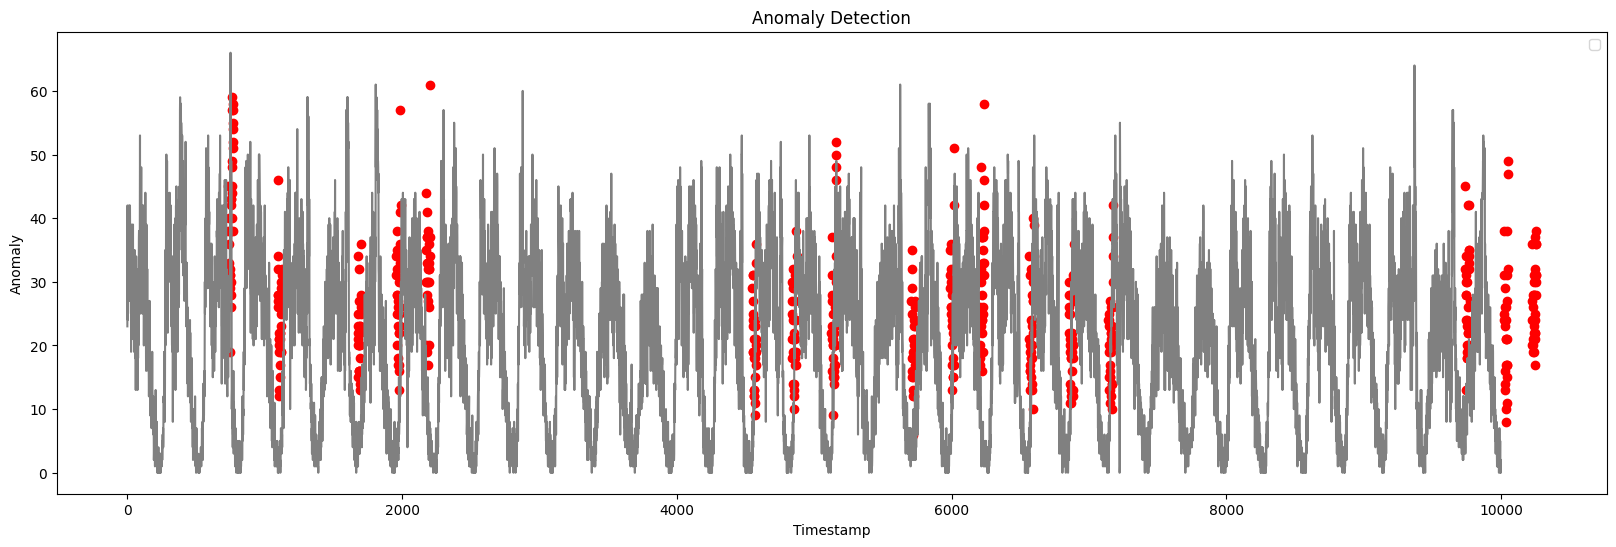

In [7]:
plt.figure(figsize=(20, 6))
plt.plot(df_sec.index, df_sec['value'], color='gray')
plt.scatter(anomaly['index'].values, anomaly['value'], color='red')
#plt.fill_between(df.index, extended_anomalies, color='red', alpha=0.3, label='Extended Anomaly')
plt.xlabel('Timestamp')
plt.ylabel('Anomaly')
plt.title('Anomaly Detection')
plt.legend()
plt.show()

### Training and Test Split

### Sliding Window for Splitting of data

First, a dummy dataframe is created.

To create a sliding window, we need the following components:

- dummy_df.values will convert the dataframe into an equivalent nd numpy array.

- np.arange(window_size)[None, :]: This will create a 2D array with values from 0 to window_size as elements of a row. We'll call this component A.

- np.arange(dummy_df.shape[0] - window_size)[:, None]: This will create a 2D array with range in the column. We'll call this component B.

If we add components A and B, we get a 2D array with <u>each row containing window_size elements and with an increment of 1 in each column</u>

In [23]:
win_size = 5

dummy_df_window = dummy_df.values[np.arange(win_size)[None, :] + np.arange(dummy_df.shape[0] - win_size)[:, None]]

dummy_df_window

NameError: name 'dummy_df' is not defined

In [24]:
from src.Components.data_processing import data_process

In [25]:
windowed_data = data_process(df)
windowed_data

array([[23, 42, 37, ..., 27, 23, 19],
       [42, 37, 24, ..., 23, 19, 22],
       [37, 24, 39, ..., 19, 22, 23],
       ...,
       [31, 43, 24, ..., 16, 14, 12],
       [43, 24, 27, ..., 14, 12,  8],
       [24, 27, 20, ..., 12,  8, 13]])

In [26]:
windowed_data.shape

(47447, 50)

In [27]:
cfg = tsfel.get_features_by_domain()

In [28]:
X = tsfel.time_series_features_extractor(cfg, windowed_data[0], verbose=0)

/tmp/ipykernel_83907/2860673602.py:1: UserWarning: Using default sampling frequency set in configuration file.
  X = tsfel.time_series_features_extractor(cfg, windowed_data[0], verbose=0)


In [30]:
X_trans = X.T